1. Visualize Branin

In [13]:
# define 
import numpy as np

def branin(x1, x2):
    a = 1.0
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6.0
    s = 10.0
    t = 1 / (8 * np.pi)

    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s

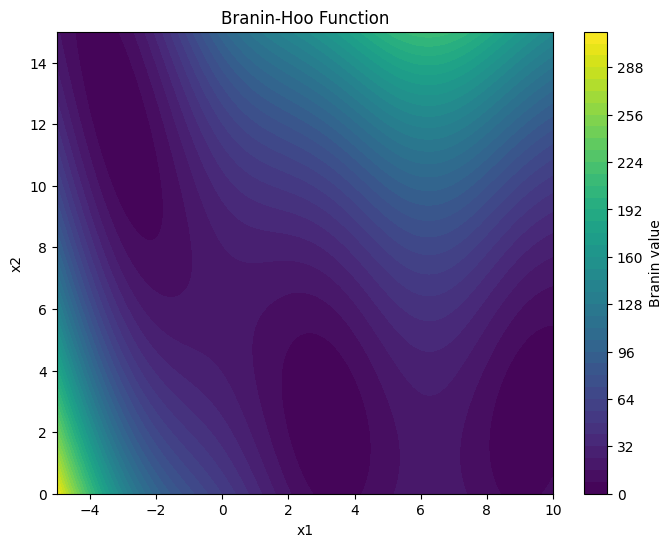

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Define input space
x1 = np.linspace(-5, 10, 200)
x2 = np.linspace(0, 15, 200)

X1, X2 = np.meshgrid(x1, x2)
Y = branin(X1, X2)

# Plot
plt.figure(figsize=(8, 6))

contour = plt.contourf(X1, X2, Y, levels=50)
plt.colorbar(contour, label="Branin value")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Branin-Hoo Function")

plt.show()

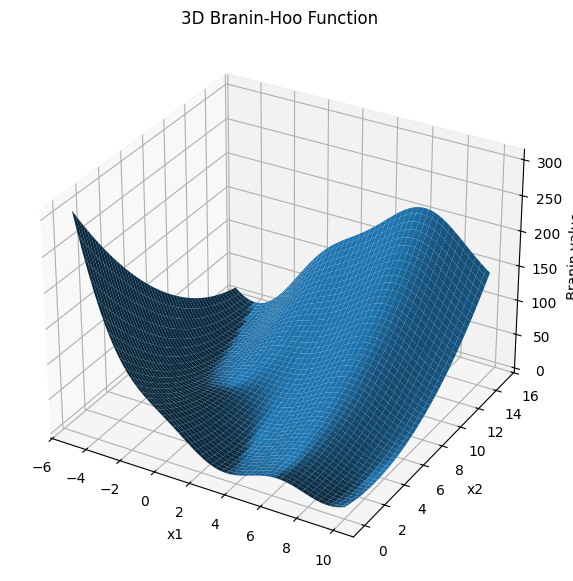

In [15]:
# 3d plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection="3d")

ax.plot_surface(X1, X2, Y)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Branin value")
ax.set_title("3D Branin-Hoo Function")

plt.show()

2. Run SMAC

In [1]:
from ConfigSpace import ConfigurationSpace, Configuration, Float
from smac import Scenario,BlackBoxFacade

# define target function
def branin_eval(config: Configuration, seed: int = 0) -> float:
    x1 = config["x1"]
    x2 = config["x2"]

    return branin(x1, x2)

# define configspace
cs = ConfigurationSpace(seed = 67)
cs.add(
    Float("x1", (-5, 10)),
    Float("x2", (0, 15))
)

# define scenario
scenario = Scenario(
    name = "branin",
    configspace = cs,
    deterministic = True,
    seed = 67,
    n_trials = 100
)

# define smac object
smac = BlackBoxFacade(
    scenario = scenario,
    target_function = branin_eval,
    #overwrite = True
)

incumbent = smac.optimize()
print(incumbent)
print( smac.runhistory.get_cost(incumbent))

[INFO][abstract_initial_design.py:143] Using 16 initial design configurations and 0 additional configurations.
[INFO][smbo.py:540] Found old run in `smac3_output\branin\67` but it is not the same as the current one: 
['scenario.n_trials: 100 != 50', 'scenario._meta.initial_design.n_configs: 16 != 12']
[INFO][abstract_intensifier.py:313] Using only one seed for deterministic scenario.
[WARNING][abstract_runner.py:136] Target function returned infinity or nothing at all. Result is treated as CRASHED and cost is set to inf.
[WARNING][abstract_runner.py:142] Traceback: Traceback (most recent call last):
  File "C:\Users\felix\Desktop\master-thesis-code\external\SMAC3\smac\runner\target_function_runner.py", line 196, in run
    rval = self(config_copy, target_function, kwargs)
  File "C:\Users\felix\Desktop\master-thesis-code\external\SMAC3\smac\runner\target_function_runner.py", line 270, in __call__
    return algorithm(config, **algorithm_kwargs)
  File "C:\Users\felix\AppData\Local\Temp

c:\Users\felix\anaconda3\envs\SMAC\lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\felix\anaconda3\envs\SMAC\lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
C:\Users\felix\Desktop\master-thesis-code\external\SMAC3\smac\model\gaussian_process\abstract_gaussian_process.py:85: RuntimeWarning: invalid value encountered in subtract
  return (y - self.mean_y_) / self.std_y_


ValueError: Input y contains NaN.

3. Visualize Optimization trajectory

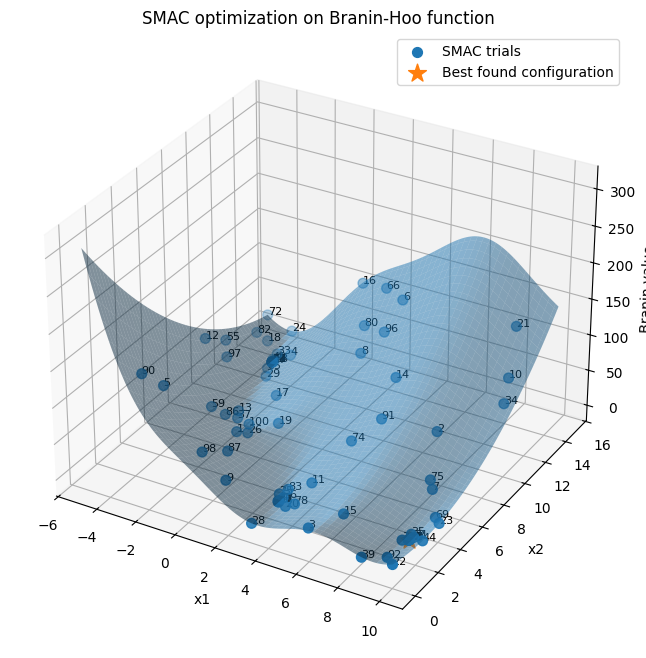

Best configuration:
{'x1': 9.4248303020869, 'x2': 2.4750135931669}
Best cost: 0.39788737181658007


In [18]:
# Create Branin surface
x1_grid = np.linspace(-5, 10, 100)
x2_grid = np.linspace(0, 15, 100)

X1, X2 = np.meshgrid(x1_grid, x2_grid)
Y = branin(X1, X2)


# Extract SMAC evaluated points
tried_x1 = []
tried_x2 = []
tried_y = []
trial_numbers = []

trials = []

for trial_key, trial_value in smac.runhistory.items():
    config = smac.runhistory.get_config(trial_key.config_id)

    trials.append({
        "x1": config["x1"],
        "x2": config["x2"],
        "cost": trial_value.cost,
        "starttime": trial_value.starttime,
    })

# Sort by evaluation time
trials = sorted(trials, key=lambda t: t["starttime"])

for i, trial in enumerate(trials, start=1):
    tried_x1.append(trial["x1"])
    tried_x2.append(trial["x2"])
    tried_y.append(trial["cost"])
    trial_numbers.append(i)


# Incumbent point
best_x1 = incumbent["x1"]
best_x2 = incumbent["x2"]
best_y = smac.runhistory.get_cost(incumbent)


# 3D plot
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(projection="3d")

# Surface
ax.plot_surface(X1, X2, Y, alpha=0.5)

# SMAC evaluated points
ax.scatter(
    tried_x1,
    tried_x2,
    tried_y,
    s=50,
    marker="o",
    label="SMAC trials",
)

# Best found point
ax.scatter(
    [best_x1],
    [best_x2],
    [best_y],
    s=180,
    marker="*",
    label="Best found configuration",
)

# Optional: annotate trial order
for i, x1, x2, y in zip(trial_numbers, tried_x1, tried_x2, tried_y):
    ax.text(x1, x2, y, str(i), fontsize=8)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Branin value")
ax.set_title("SMAC optimization on Branin-Hoo function")
ax.legend()

plt.show()


print("Best configuration:")
print(dict(incumbent))
print("Best cost:", best_y)

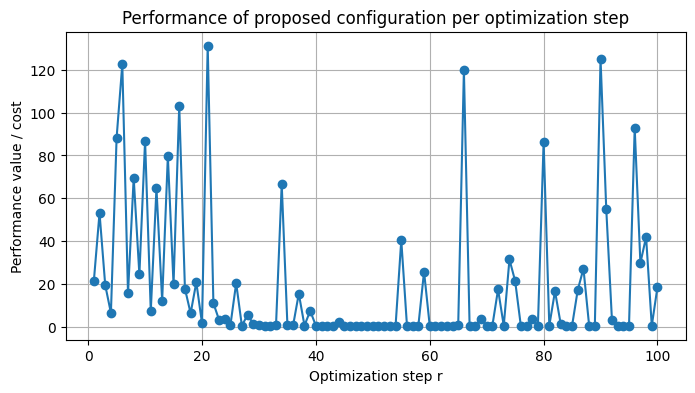

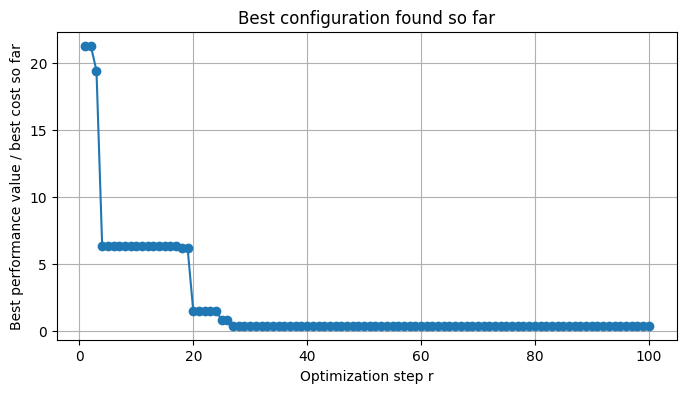

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Extract trials from SMAC runhistory
trials = []

for trial_key, trial_value in smac.runhistory.items():
    config = smac.runhistory.get_config(trial_key.config_id)

    trials.append({
        "config_id": trial_key.config_id,
        "config": dict(config),
        "cost": trial_value.cost,
        "starttime": trial_value.starttime,
    })

# Sort by actual evaluation order
trials = sorted(trials, key=lambda t: t["starttime"])

# Optimization steps: r = 1, 2, ..., number of trials
r = np.arange(1, len(trials) + 1)

# Performance value of proposed configuration at each step
costs = np.array([t["cost"] for t in trials])

# Best performance found so far
best_so_far = np.minimum.accumulate(costs)

# ---------------------------------------------------------
# 1. Performance value of proposed configuration per step
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(r, costs, marker="o")

ax.set_xlabel("Optimization step r")
ax.set_ylabel("Performance value / cost")
ax.set_title("Performance of proposed configuration per optimization step")
ax.grid(True)

plt.show()


# ---------------------------------------------------------
# 2. Performance value of best configuration found so far
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(r, best_so_far, marker="o")

ax.set_xlabel("Optimization step r")
ax.set_ylabel("Best performance value / best cost so far")
ax.set_title("Best configuration found so far")
ax.grid(True)

plt.show()

In [ ]:
print(smac.scenario)
smac.validate

Scenario(configspace=Configuration space object:
  Hyperparameters:
    x1, Type: UniformFloat, Range: [-5.0, 10.0], Default: 2.5
    x2, Type: UniformFloat, Range: [0.0, 15.0], Default: 7.5
, name='branin', output_directory=WindowsPath('smac3_output/branin/67'), deterministic=True, objectives='cost', crash_cost=inf, termination_cost_threshold=inf, walltime_limit=inf, cputime_limit=inf, trial_walltime_limit=None, trial_memory_limit=None, n_trials=100, use_default_config=False, instances=None, instance_features=None, adaptive_capping=False, adaptive_capping_slackfactor=None, runtime_cutoff=None, min_budget=None, max_budget=None, seed=67, n_workers=1)
